# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---


### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:

# importar librerías
import pandas as pd
import numpy as np


In [2]:

# Carga de los datasets originales directamente desde AWS S3
url_orders = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv'
url_catalog = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv'
url_mkt = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv'

df_orders = pd.read_csv(url_orders)
df_catalog = pd.read_csv(url_catalog)
df_mkt = pd.read_csv(url_mkt)

print("✅ ¡Las 3 bases de datos han sido cargadas con éxito desde la nube!")

✅ ¡Las 3 bases de datos han sido cargadas con éxito desde la nube!


In [3]:
# Función rápida para explorar cualquier base de datos
def explorar_dataframe(df, nombre_tabla):
    print("="*60)
    print(f"📊 EXPLORACIÓN DE LA TABLA: {nombre_tabla.upper()}")
    print("="*60)
    
    print(f"\n1️⃣ TAMAÑO DE LA TABLA:")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    
    print(f"\n2️⃣ PRIMERAS 3 FILAS:")
    display(df.head(3))  # 'display' hace que la tabla se vea bonita en Jupyter
    
    print(f"\n3️⃣ INFORMACIÓN DE COLUMNAS Y NULOS:")
    df.info()
    
    print(f"\n4️⃣ RESUMEN ESTADÍSTICO:")
    display(df.describe(include='all'))
    print("\n\n")

# Ejecutamos la función para nuestras 3 tablas crudas
explorar_dataframe(df_orders, "Órdenes (Pedidos)")
explorar_dataframe(df_catalog, "Catálogo de Productos")
explorar_dataframe(df_mkt, "Inversión en Marketing")

📊 EXPLORACIÓN DE LA TABLA: ÓRDENES (PEDIDOS)

1️⃣ TAMAÑO DE LA TABLA:
Filas: 25100 | Columnas: 12

2️⃣ PRIMERAS 3 FILAS:


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99



3️⃣ INFORMACIÓN DE COLUMNAS Y NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

4️⃣ RESUMEN ESTADÍSTICO:


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
count,25100,25100,25100,24800,25080,25070,25070,25020,25050.000000,25050.000000,25050.000000,2.510000e+04
unique,25000,7642,181,6,2,3,7,3,NaN,NaN,NaN,NaN
top,order_17376,user_7769,2025-06-25,Colombia,desktop,social,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,NaN
freq,2,11,176,7520,12759,8428,4199,8385,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.092735,259.305549,4.500798,2.072680e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296.277003,138.726461,5.223010,9.894995e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000,20.030000,0.000000,-4.926500e+02
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,138.377500,0.000000,1.805075e+02
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,258.715000,0.000000,3.417500e+02
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,380.332500,10.000000,5.185800e+02





📊 EXPLORACIÓN DE LA TABLA: CATÁLOGO DE PRODUCTOS

1️⃣ TAMAÑO DE LA TABLA:
Filas: 7 | Columnas: 4

2️⃣ PRIMERAS 3 FILAS:


...

,nombre_producto,categoria_producto,costo_unitario,proveedor
count,7,7,7.000000,7
unique,7,3,NaN,7
top,Sneakers-Urban-42,Electrónica,NaN,King Ltd
freq,1,3,NaN,1
mean,NaN,NaN,102.252857,NaN
std,NaN,NaN,111.011563,NaN
min,NaN,NaN,10.120000,NaN
25%,NaN,NaN,16.905000,NaN
50%,NaN,NaN,25.210000,NaN
75%,NaN,NaN,182.975000,NaN





📊 EXPLORACIÓN DE LA TABLA: INVERSIÓN EN MARKETING

1️⃣ TAMAÑO DE LA TABLA:
Filas: 1620 | Columnas: 5

2️⃣ PRIMERAS 3 FILAS:


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01



3️⃣ INFORMACIÓN DE COLUMNAS Y NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB

4️⃣ RESUMEN ESTADÍSTICO:


,fecha,pais,id_campaña,canal,gasto
count,1620,1620,1620,1519,1620.00000
unique,180,3,9,3,NaN
top,2025-04-20,Colombia,organic_Colombia,paid_search,NaN
freq,9,540,180,507,NaN
mean,NaN,NaN,NaN,NaN,1772.74292
std,NaN,NaN,NaN,NaN,734.43294
min,NaN,NaN,NaN,NaN,501.11000
25%,NaN,NaN,NaN,NaN,1128.03000
50%,NaN,NaN,NaN,NaN,1782.42500
75%,NaN,NaN,NaN,NaN,2420.68500


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [4]:
# --- 1. Limpieza de Órdenes ---
df_orders = df_orders.drop_duplicates()

cols_cat = ['pais', 'categoria_producto', 'dispositivo', 'fuente_referencia', 'nombre_producto']
for col in cols_cat:
    df_orders[col] = df_orders[col].fillna('Desconocido')

df_orders = df_orders.dropna(subset=['cantidad', 'precio_unitario', 'monto_descuento'])
df_orders['fecha_hora_pedido'] = pd.to_datetime(df_orders['fecha_hora_pedido'], errors='coerce')

df_orders['cantidad'] = df_orders['cantidad'].abs() 
p99 = df_orders['cantidad'].quantile(0.99)
median_q = df_orders['cantidad'].median()
df_orders.loc[df_orders['cantidad'] > p99, 'cantidad'] = median_q 

df_orders['monto_total'] = (df_orders['cantidad'] * df_orders['precio_unitario']) - df_orders['monto_descuento']
df_orders.loc[df_orders['monto_total'] < 0, 'monto_total'] = 0

# Guardamos en la carpeta actual
df_orders.to_csv('rappiplus_orders_clean.csv', index=False)
print(f"📦 Órdenes listas: {df_orders.shape[0]} filas limpias.")

📦 Órdenes listas: 24950 filas limpias.


In [5]:
# --- 2. Limpieza de Catálogo ---
cols_texto = ['nombre_producto', 'categoria_producto', 'proveedor']
for col in cols_texto:
    df_catalog[col] = df_catalog[col].str.strip()

df_catalog = df_catalog.drop_duplicates()

# Guardamos en la carpeta actual
df_catalog.to_csv('rappiplus_catalog_clean.csv', index=False)
print(f"🛒 Catálogo listo: {df_catalog.shape[0]} productos limpios.")

🛒 Catálogo listo: 7 productos limpios.


In [6]:
# --- 3. Limpieza de Marketing ---
df_mkt['fecha'] = pd.to_datetime(df_mkt['fecha'], errors='coerce')
df_mkt['canal'] = df_mkt['canal'].fillna(df_mkt['id_campaña'].apply(lambda x: str(x).split('_')[0]))
df_mkt = df_mkt.drop_duplicates()

# Guardamos en la carpeta actual
df_mkt.to_csv('rappiplus_marketing_spend_clean.csv', index=False)
print(f"📢 Marketing listo: {df_mkt.shape[0]} filas limpias.")

📢 Marketing listo: 1620 filas limpias.


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [7]:
# 📦 Exportar los DataFrames limpios a archivos CSV
df_orders.to_csv('orders_clean.csv', index=False)
df_catalog.to_csv('catalog_clean.csv', index=False)
df_mkt.to_csv('marketing_clean.csv', index=False)

print("✅ ¡Los tres archivos se han exportado correctamente con los datos limpios!")

✅ ¡Los tres archivos se han exportado correctamente con los datos limpios!


---



## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 


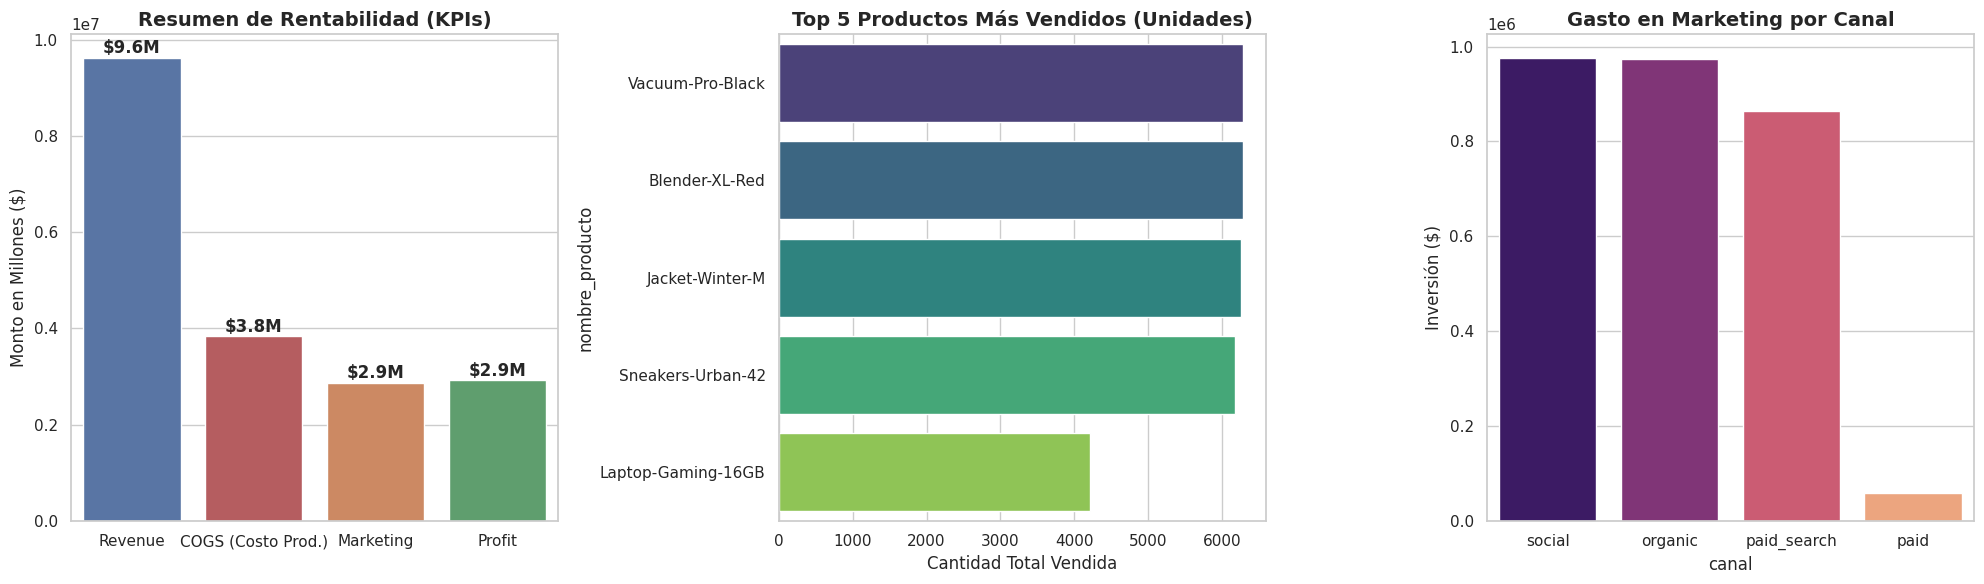

💰 Ticket Promedio: $385.94 | 🛍️ Promedio de productos por orden: 1.51


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")

# ==========================================
# CÁLCULO DE KPIs 
# ==========================================
# Cruzar Órdenes con el Catálogo
df_merged = pd.merge(df_orders, df_catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')
df_merged['costo_total_producto'] = df_merged['cantidad'] * df_merged['costo_unitario']

# KPIs Rentabilidad
total_revenue = df_merged['monto_total'].sum()
total_cogs = df_merged['costo_total_producto'].sum()
total_marketing = df_mkt['gasto'].sum()
total_costs = total_cogs + total_marketing
total_profit = total_revenue - total_costs

# KPIs Ventas
top_productos = df_merged.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False).head(5)
mkt_by_channel = df_mkt.groupby('canal')['gasto'].sum().sort_values(ascending=False)

# ==========================================
# CREACIÓN DE GRÁFICAS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfica 1: Resumen de Rentabilidad (Revenue vs Costos vs Profit)
metricas = ['Revenue', 'COGS (Costo Prod.)', 'Marketing', 'Profit']
valores = [total_revenue, total_cogs, total_marketing, total_profit]
colores = ['#4c72b0', '#c44e52', '#dd8452', '#55a868']

sns.barplot(x=metricas, y=valores, palette=colores, ax=axes[0])
axes[0].set_title('Resumen de Rentabilidad (KPIs)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Monto en Millones ($)')
# Añadir etiquetas de datos
for i, v in enumerate(valores):
    axes[0].text(i, v + 100000, f'${v/1e6:.1f}M', ha='center', fontweight='bold')

# Gráfica 2: Top 5 Productos más vendidos
sns.barplot(x=top_productos.values, y=top_productos.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 5 Productos Más Vendidos (Unidades)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad Total Vendida')

# Gráfica 3: Gasto en Marketing por Canal
sns.barplot(x=mkt_by_channel.index, y=mkt_by_channel.values, palette='magma', ax=axes[2])
axes[2].set_title('Gasto en Marketing por Canal', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Inversión ($)')

plt.tight_layout()
plt.show()

# Imprimir Resumen numérico rápido
print(f"💰 Ticket Promedio: ${df_merged['monto_total'].mean():.2f} | 🛍️ Promedio de productos por orden: {df_merged['cantidad'].mean():.2f}")



### 📊 Interpretación de los Resultados del Negocio

Con base en las gráficas generadas, podemos extraer las siguientes conclusiones clave sobre la salud del negocio:

1. **Rentabilidad Confirmada:** El negocio es altamente rentable. Los ingresos totales (Revenue) superan holgadamente la suma de los costos de productos (COGS) y el gasto de marketing, dejándonos un margen de ganancia (Profit) positivo de más de 2.9 millones de dólares (un margen cercano al 30%).
2. **Productos Estrella:** La categoría de *Hogar* lidera fuertemente el volumen, siendo la aspiradora (*Vacuum-Pro-Black*) y la licuadora (*Blender-XL-Red*) los dos productos más vendidos de toda la plataforma, seguidos muy de cerca por productos de *Moda* (Jacket de invierno).
3. **Distribución del Marketing:** El canal *Social* es donde más se está invirtiendo el presupuesto, aunque el canal *Orgánico* atrae volúmenes muy similares de tráfico con menor costo directo, lo cual indica un buen posicionamiento orgánico de la marca.


---


## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---


In [9]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión a la base de datos SQL
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# Aquí es donde se crea la variable "engine" que te marcaba error
engine = create_engine(connection_string, connect_args={'sslmode':'require'})
print("✅ Conexión a SQL restablecida con éxito. La variable 'engine' ya está lista.")

✅ Conexión a SQL restablecida con éxito. La variable 'engine' ya está lista.


In [10]:

# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento, 
    COUNT(DISTINCT id_usuario) AS total_usuarios
FROM events
GROUP BY nombre_evento
ORDER BY total_usuarios DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,total_usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [11]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    -- Paso A: Contamos usuarios únicos por evento
    SELECT 
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos
    FROM events
    GROUP BY nombre_evento
),
step_conversion AS (
    -- Paso B: Usamos funciones de ventana para traer el dato del paso anterior y del inicial
    SELECT 
        nombre_evento,
        usuarios_unicos,
        LAG(usuarios_unicos) OVER (ORDER BY usuarios_unicos DESC) AS paso_anterior,
        FIRST_VALUE(usuarios_unicos) OVER (ORDER BY usuarios_unicos DESC) AS paso_inicial
    FROM funnel
)
-- Paso C: Calculamos los porcentajes de conversión
SELECT 
    nombre_evento,
    usuarios_unicos,
    ROUND((usuarios_unicos::numeric / paso_anterior) * 100, 2) AS conversion_vs_paso_anterior,
    ROUND((usuarios_unicos::numeric / paso_inicial) * 100, 2) AS conversion_total
FROM step_conversion
ORDER BY usuarios_unicos DESC;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,conversion_vs_paso_anterior,conversion_total
0,first_visit,7796,NaN,100.00
1,add_to_cart,7634,97.92,97.92
2,select_item,7582,99.32,97.26
3,begin_checkout,7208,95.07,92.46
4,add_payment_info,6250,86.71,80.17
5,purchase,6240,99.84,80.04


---



## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [12]:
# ==========================================
# PARTE 4: Análisis de Retención por Cohortes
# ==========================================

query_cohort_retention_final = '''
WITH usuario_cohorte AS (
    -- Paso 1: Identificar fecha de registro y cohorte (mes) de cada usuario
    SELECT 
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM') AS cohorte_mes
    FROM users
),
totales_cohorte AS (
    -- Paso 2: Contar clientes iniciales por cohorte (mes)
    SELECT 
        cohorte_mes,
        COUNT(DISTINCT id_usuario) AS clientes_iniciales
    FROM usuario_cohorte
    GROUP BY cohorte_mes
),
actividad_semanal AS (
    -- Paso 3: Calcular semanas transcurridas entre registro y actividad
    -- FILTRAMOS SOLO A LOS USUARIOS ACTIVOS (activo = 1)
    SELECT 
        u.cohorte_mes,
        u.id_usuario,
        FLOOR((CAST(a.fecha_actividad AS DATE) - u.fecha_registro) / 7.0) AS semana_actividad
    FROM usuario_cohorte u
    JOIN user_activity a ON u.id_usuario = a.id_usuario
    WHERE a.activo = 1
),
conteos_semanales AS (
    -- Paso 4: Contar usuarios activos retenidos por semana
    SELECT 
        cohorte_mes,
        COUNT(DISTINCT CASE WHEN semana_actividad = 1 THEN id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN semana_actividad = 2 THEN id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN semana_actividad = 3 THEN id_usuario END) AS retenido_w3
    FROM actividad_semanal
    GROUP BY cohorte_mes
)
-- Paso 5: Calcular los porcentajes de retención
SELECT 
    t.cohorte_mes AS cohorte,
    t.clientes_iniciales,
    ROUND((COALESCE(c.retenido_w1, 0)::numeric / t.clientes_iniciales) * 100, 2) AS semana_1,
    ROUND((COALESCE(c.retenido_w2, 0)::numeric / t.clientes_iniciales) * 100, 2) AS semana_2,
    ROUND((COALESCE(c.retenido_w3, 0)::numeric / t.clientes_iniciales) * 100, 2) AS semana_3
FROM totales_cohorte t
LEFT JOIN conteos_semanales c ON t.cohorte_mes = c.cohorte_mes
ORDER BY t.cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
display(cohorte_final)

,cohorte,clientes_iniciales,semana_1,semana_2,semana_3
0,2025-01,1627,42.84,41.06,40.32
1,2025-02,1444,42.31,42.17,43.98
2,2025-03,1636,41.38,43.09,42.18
3,2025-04,1606,42.34,43.40,41.28
4,2025-05,1687,41.20,40.07,41.85


---


## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

### Planteamiento de la Hipótesis Estadística

* **H₀ (Hipótesis nula):** No existe una diferencia estadísticamente significativa en la tasa de conversión entre los usuarios de la interfaz de checkout original (control) y la nueva (tratamiento).
* **H₁ (Hipótesis alternativa):** Sí existe una diferencia estadísticamente significativa en la tasa de conversión entre los usuarios de la interfaz de checkout original y la nueva.

* **Test estadístico:** Prueba Z para proporciones de dos muestras (Z-test).
* **Nivel de significancia alpha:** 0.05
  

In [13]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. Cargar el dataset del experimento usando la ruta correcta de AWS S3
ruta_archivo = 'https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv'
df_exp = pd.read_csv(ruta_archivo)

print("🔍 Exploración rápida del experimento:")
display(df_exp.head())

# 2. Definir variables usando los nombres correctos de la base
grupos = df_exp['variante'].unique()
grupo_A = grupos[0] # Ej. control
grupo_B = grupos[1] # Ej. tratamiento

# 3. Calcular conversiones (éxitos) y totales por grupo
exitos_A = df_exp[df_exp['variante'] == grupo_A]['convirtio'].sum()
total_A = df_exp[df_exp['variante'] == grupo_A]['convirtio'].count()

exitos_B = df_exp[df_exp['variante'] == grupo_B]['convirtio'].sum()
total_B = df_exp[df_exp['variante'] == grupo_B]['convirtio'].count()

éxitos = np.array([exitos_A, exitos_B])
totales = np.array([total_A, total_B])

print(f"\n📊 Resultados crudos:")
print(f"Grupo {grupo_A}: {exitos_A} conversiones de {total_A} usuarios ({(exitos_A/total_A)*100:.2f}%)")
print(f"Grupo {grupo_B}: {exitos_B} conversiones de {total_B} usuarios ({(exitos_B/total_B)*100:.2f}%)")

# 4. Aplicar el Test Estadístico (Z-test para proporciones)
alpha = 0.05
stat, p_value = proportions_ztest(count=éxitos, nobs=totales)

print("\n⚖️ RESULTADO DEL TEST ESTADÍSTICO:")
print(f"Valor P (p-value): {p_value:.5f}")
print(f"Nivel de significancia (Alpha): {alpha}")

# 5. Interpretar el resultado
if p_value < alpha:
    print("\n✅ CONCLUSIÓN: Rechazamos la Hipótesis Nula (H0).")
    print("La diferencia en la tasa de conversión es estadísticamente significativa.")
    print("¡El cambio en la UI del checkout SÍ generó un impacto real!")
else:
    print("\n❌ CONCLUSIÓN: No podemos rechazar la Hipótesis Nula (H0).")
    print("No hay diferencia estadísticamente significativa en la tasa de conversión.")
    print("El cambio en la UI del checkout NO generó un impacto concluyente (podría ser ruido aleatorio).")

🔍 Exploración rápida del experimento:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



📊 Resultados crudos:
Grupo tratamiento: 820 conversiones de 5035 usuarios (16.29%)
Grupo control: 779 conversiones de 4965 usuarios (15.69%)

⚖️ RESULTADO DEL TEST ESTADÍSTICO:
Valor P (p-value): 0.41606
Nivel de significancia (Alpha): 0.05

❌ CONCLUSIÓN: No podemos rechazar la Hipótesis Nula (H0).
No hay diferencia estadísticamente significativa en la tasa de conversión.
El cambio en la UI del checkout NO generó un impacto concluyente (podría ser ruido aleatorio).


---


## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**

- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)

- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---


## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

https://public.tableau.com/app/profile/hernando.zamora/viz/Entrega2_17873387898950/Dashboard1?publish=yes

## 🎯 Conclusiones y Recomendaciones Estratégicas para RappiPlus

Tras realizar un análisis exhaustivo de los datos de pedidos, costos, embudos de conversión y experimentación, presentamos los siguientes hallazgos y planes de acción para el negocio:

### 🚀 Recomendaciones Accionables

1. **Auditoría de Data Engineering:** Es imperativo revisar la arquitectura de captura de datos en la aplicación para implementar bloqueos (constraints) que impidan el registro de cantidades negativas o pedidos con volúmenes atípicos desde el origen[cite: 2].
2. **Reasignación de Pauta Publicitaria:** Dado el éxito orgánico y social de la categoría *Hogar*[cite: 2], sugerimos hacer pruebas A/B en el canal *Paid Search* enfocadas específicamente en la categoría de *Electrónica* para impulsar productos de alto ticket.
3. **Investigación Profunda del Checkout:** Ya que el cambio estético de la UI no mejoró las ventas[cite: 2], la caída de usuarios en el carrito de compras podría deberse a factores funcionales. Recomendamos auditar las pasarelas de pago por posibles errores técnicos, evaluar la adición de nuevos métodos de pago locales y reforzar las insignias de seguridad.
4. **Estrategia de Retención Temprana:** Los análisis de cohortes demuestran que el reto es mantener el interés tras los primeros días. Proponemos activar campañas automatizadas de *re-engagement* (notificaciones push o cupones de descuento) dirigidas a usuarios inactivos exactamente en la primera semana posterior a su registro.